# FuseMap Tutorial 8: Deconvolving Bead-Resolution Data (Slide-seq)

Bead/spot technologies (Slide-seq, Visium HD) measure **mixtures of cells**, so their raw
embeddings sit apart from true single-cell data. FuseMap's **Stage-B deconvolution** fixes this
after integration:

1. learn ~40 cell **archetypes** from the integrated single-cell latents,
2. build each archetype's expression **signature** on the bead gene panel,
3. decompose every bead into a mixture **π** over archetypes (with per-gene platform terms),
4. rebuild the bead's cell embedding as `π @ archetypes` and its tissue embedding by spatial averaging.

Data: four mouse brain sections — STARmap PLUS (healthy), Stereo-seq, STARmap PLUS (TauPS2APP AD), and a **Slide-seq puck** (beads).

**Runtime**: integration ~hours (GPU) — a `precomputed_output/` folder ships with the download
so you can skip straight to Stage-B (~30 min) or straight to the analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import scanpy as sc

## 1. Download the example data

In [ ]:
import gdown

FILES = {
    "13months-disease-replicate_1.h5ad": "1vt9TkXTuD_TIzGGcO-brMoZoj7r8dHmK",
    "precomputed_output/ad_celltype_embedding.h5ad": "1vFU6oXyMJYXKZSZSKDrXJi8FW7ajC_GG",
    "precomputed_output/ad_celltype_embedding_stageB.h5ad": "1hiVmTDrxVeWvi-ECsWTymeidCWg6hr4h",
    "precomputed_output/ad_gene_embedding.h5ad": "1XKyCqhajlCVKkDRs-bNG7ujDKjEIqS3x",
    "precomputed_output/ad_tissueregion_embedding.h5ad": "1ql1k_Vhrwhl9Ccf7GlDOcqcxP-izfs16",
    "precomputed_output/ad_tissueregion_embedding_stageB.h5ad": "1B4_W2FzXyKgspklI6SoXcstkUmtzp1WK",
    "precomputed_output/latent_embeddings_all_single_final.pkl": "1UHCulvwtjyEX_kk8eRnZiOkDJOpZvaaG",
    "precomputed_output/latent_embeddings_all_spatial_final.pkl": "1rA5G5ai-RrL_DcLl2wDdk78Qg3qPfaHe",
    "precomputed_output/stageB_pi.npz": "1DzkJ-PWQICeCKLHHAU_hCyRUPZhVE9K7",
    "precomputed_output/trained_model/FuseMap_final_model_final.pt": "1HkqHjm1TX45QOSNCo1csPmTnQJj71rxh",
    "section1.h5ad": "1RoyaFMP1eHZW3XlyFQuH7YxWJ3wzQfSl",
    "slideseq_Puck60.h5ad": "1dkJ7CZhE0qQhOXEG5_wchfMva5a-xDK1",
    "stereoseq_mousebrain.h5ad": "1ELAKFv3lfGgAjBpZKupZvtEHNbFPQing",
}
base = "./tutorial_data/tutorial8_bead_deconvolution"
for rel, fid in FILES.items():
    out = os.path.join(base, rel)
    if not os.path.exists(out):
        os.makedirs(os.path.dirname(out), exist_ok=True)
        gdown.download(id=fid, output=out, quiet=False)

## 2. Integrate the four sections

Skipped automatically if you copied `precomputed_output/` to `./output_tutorial8` (as below) —
delete that folder to train from scratch.

In [3]:
import fusemap, shutil

if not os.path.exists("./output_tutorial8"):
    shutil.copytree("./tutorial_data/tutorial8_bead_deconvolution/precomputed_output",
                    "./output_tutorial8")

if not os.path.exists("./output_tutorial8/ad_celltype_embedding.h5ad"):
    fusemap.integrate("./tutorial_data/tutorial8_bead_deconvolution", "./output_tutorial8")

## 3. Stage-B deconvolution — one call

**You** declare the dataset roles (nothing is auto-detected): `bead_files` selects the
bead-resolution dataset(s), `sig_ref` the single-cell dataset(s) whose expression builds the
archetype signatures. Each argument is a comma-separated list of file-name substrings.

In [4]:
fusemap.deconvolve_beads("./output_tutorial8", "./tutorial_data/tutorial8_bead_deconvolution",
                         bead_files="slideseq_Puck60", sig_ref="stereoseq")

[env] device=cuda  CUDA_VISIBLE_DEVICES=1


[env] atlas order (os.listdir): ['section1.h5ad', '13months-disease-replicate_1.h5ad', 'stereoseq_mousebrain.h5ad', 'slideseq_Puck60.h5ad']


[env] DATA_DIR=./tutorial_data/tutorial8_bead_deconvolution/  OUT_DIR=./output_tutorial8/


[env] bead datasets: ['slideseq_Puck60.h5ad']


[latents] shapes: [(9002, 64), (10372, 64), (50140, 64), (54787, 64)]


...

[eval ii] Isocortex beads (n=12456) -> EX L2/3|L4|L5/6|L6 frac in 30 NN reference:


          Stage-B (new) = 0.159   [recomputed Stage-A orig = 0.098; reported Stage-A = 0.167; chance ~0.086]


[eval iii] iLISI stereoseq_mousebrain<->slideseq_Puck60 (k=50, range [1,2], higher=more mixed):


          Stage-B (new) = 1.1740   [recomputed Stage-A orig = 1.6457]



[done] Stage-B deconvolution complete.


## 4. Before vs after

Compare the tissue embedding with the puck's **native** rows vs its **Stage-B** rows:
the beads move into the shared tissue-region manifold.

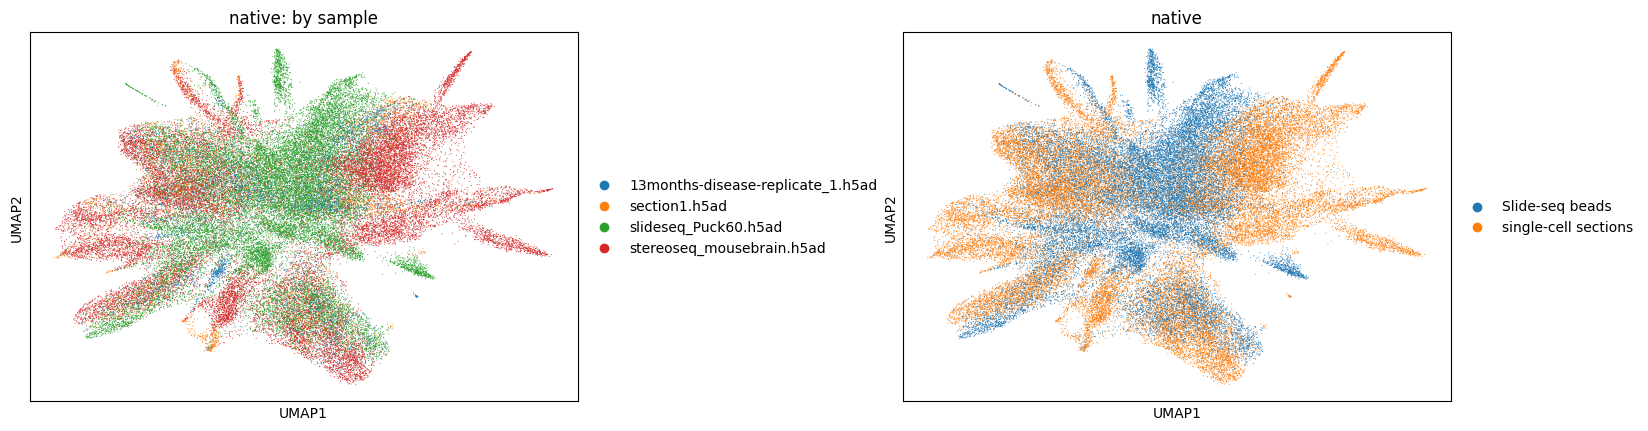

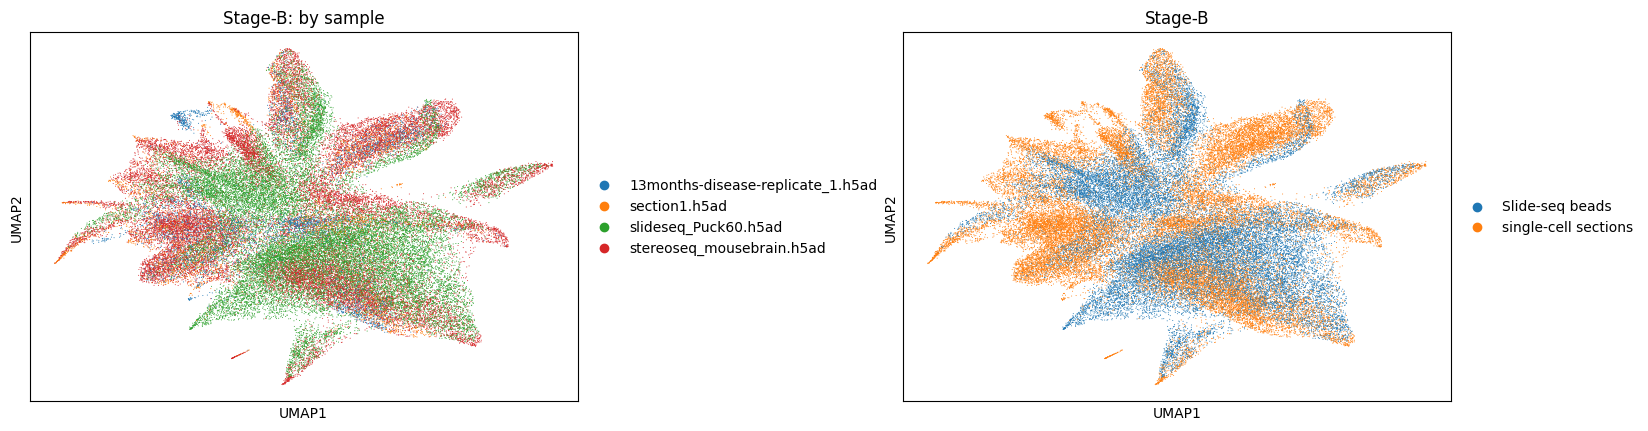

In [5]:
def umap_view(path, title):
    ad_t = sc.read_h5ad(path)
    if ad_t.n_obs > 60000:
        sc.pp.subsample(ad_t, n_obs=60000, random_state=0)
    sc.pp.neighbors(ad_t, use_rep="X", n_neighbors=30)
    sc.tl.umap(ad_t)
    ad_t.obs["is_bead"] = np.where(ad_t.obs["file_name"].str.contains("slideseq"),
                                   "Slide-seq beads", "single-cell sections")
    sc.pl.umap(ad_t, color=["file_name", "is_bead"], title=[title + ": by sample", title], wspace=0.45)

umap_view("./output_tutorial8/ad_tissueregion_embedding.h5ad", "native")
umap_view("./output_tutorial8/ad_tissueregion_embedding_stageB.h5ad", "Stage-B")

## 5. The mixture matrix π

`stageB_pi.npz` stores per-bead archetype weights — a free deconvolution readout:
entropy shows how mixed each bead is, and the dominant archetype gives a hard assignment.

pi: (54787, 40) (beads x archetypes), rows sum to [1. 1. 1.]


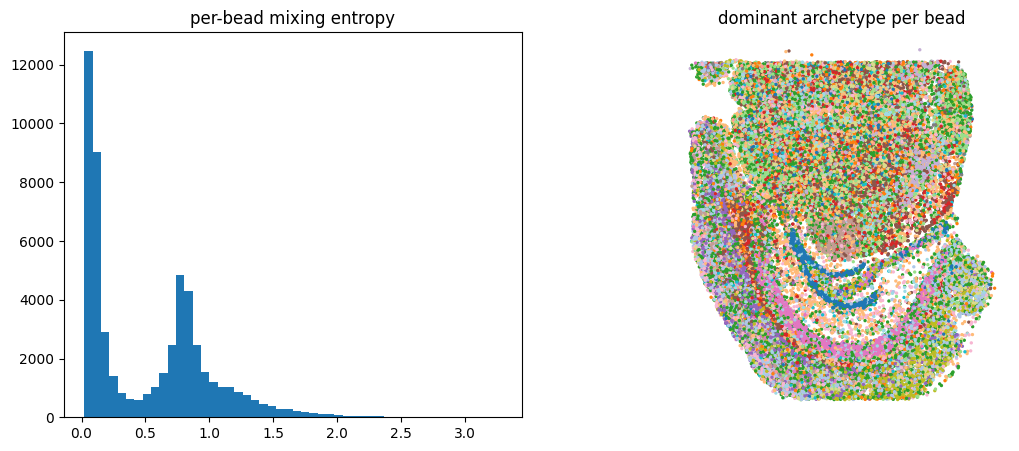

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

z = np.load("./output_tutorial8/stageB_pi.npz", allow_pickle=True)
pi = z["pi"]
print("pi:", pi.shape, "(beads x archetypes), rows sum to", pi.sum(1)[:3].round(3))

entropy = -(pi * np.log(pi + 1e-12)).sum(1)
ad_bead = sc.read_h5ad("./output_tutorial8/ad_celltype_embedding_stageB.h5ad")
bead_obs = ad_bead.obs[ad_bead.obs["file_name"].str.contains("slideseq")]
bx, by = pd.to_numeric(bead_obs["x"]), pd.to_numeric(bead_obs["y"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(entropy, bins=50); axes[0].set_title("per-bead mixing entropy")
axes[1].scatter(bx, by, c=pi.argmax(1), cmap="tab20", s=2)
axes[1].set_title("dominant archetype per bead"); axes[1].set_aspect("equal"); axes[1].axis("off")
plt.show()

## Which embedding should I use?

- **Tissue-level analysis / visualization** → Stage-B tissue embedding (`*_tissueregion_embedding_stageB.h5ad`)
- **Cell-level analysis of the single-cell sections** → native cell embedding
- **Bead composition questions** ("what is this bead made of?") → `π`

See the [Parameters](https://fusemap.readthedocs.io/en/latest/userguide/parameters.html) page for
`entropy_weight` / `signature_mode` knobs (defaults are validated — normally leave them).